##MemoTag Speech Intelligence Module

In [2]:
!pip install librosa
!pip install pydub
!pip install soundfile
!pip install SpeechRecognition
!pip install spacy
!pip install jinja2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 18.8 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
import speech_recognition as sr
import nltk
import warnings
import os
import traceback
from transformers import pipeline
import spacy
import jinja2

In [18]:
def download_nltk_resources():
    try:
        nltk.download('punkt')
        nltk.download('punkt_tab')
        nltk.download('stopwords')
        return True
    except Exception as e:
        print("Error downloading NLTK resources:", e)
        return False


# 1. Forced Alignment for Pause per Sentence

In [5]:
def forced_alignment_sentence_pauses(audio_path, transcription):

    # Pseudocode / placeholder:
    sentence_boundaries = []
    return {'pauses_per_sentence': pauses_per_sentence}

# 2. Word Recall/Substitution Tracking via Semantic Mismatch

In [6]:
def detect_word_substitution(transcription):

    substitution_score = 0

    classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

    # Define a list of filler words that might indicate substitution issues:
    filler_words = ['thing', 'stuff']
    candidate_sentences = nltk.sent_tokenize(transcription)

    for sent in candidate_sentences:
        for filler in filler_words:
            if filler in sent.lower():
                result = classifier(sent, candidate_labels=["object misuse", "correct usage"])
                if result['labels'][0] == "object misuse":
                    substitution_score += 1

    # Normalize score by number of sentences
    substitution_rate = substitution_score / len(candidate_sentences) if candidate_sentences else 0
    return {'word_substitution_rate': substitution_rate}

# 3. Task-Specific Feature Extraction

In [7]:
def task_specific_features(transcription, expected_responses=None):

    features = {}
    if expected_responses:
        for task, expected in expected_responses.items():
            # Simple matching: check if expected words are present in transcription.
            count_found = sum(1 for word in expected if word.lower() in transcription.lower())
            features[f'{task}_missing'] = len(expected) - count_found
    else:
        # If no tasks defined, set defaults.
        features['naming_task_missing'] = 0
        features['sentence_completion_incomplete'] = 0
    return features

# 4. Speech Rate Calculation as Words Per Minute (WPM)

In [8]:
def calculate_wpm(text, duration):
    words = nltk.word_tokenize(text)
    wpm = (len(words) / duration * 60) if duration > 0 else 0
    return wpm

# 5. Sentence Completion Detection Using Dependency Parsing

In [9]:
def detect_incomplete_sentences(text):
    if not text or nlp is None:
        return {'incomplete_sentence_rate': 0}

    doc = nlp(text)
    sentences = list(doc.sents)
    incomplete_count = 0
    for sent in sentences:


        if not any(token.dep_ == "ROOT" for token in sent) or len(sent) < 3:
            incomplete_count += 1
    rate = incomplete_count / len(sentences) if sentences else 0
    return {'incomplete_sentence_rate': rate}

# 6. Existing Audio Feature Extraction & Transcription Functions

In [10]:
def extract_audio_features(audio_path):
    try:
        y, sr = librosa.load(audio_path, sr=None)
        duration = librosa.get_duration(y=y, sr=sr)
        non_silent_intervals = librosa.effects.split(y, top_db=20)
        pauses = len(non_silent_intervals) - 1
        pause_duration = duration - sum([(end - start) / sr for start, end in non_silent_intervals])
        pause_rate = pauses / duration if duration > 0 else 0

        pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
        pitches_nonzero = pitches[pitches > 0]
        pitch_mean = np.mean(pitches_nonzero) if len(pitches_nonzero) > 0 else 0
        pitch_std = np.std(pitches_nonzero) if len(pitches_nonzero) > 0 else 0

        onset_env = librosa.onset.onset_strength(y=y, sr=sr)
        onsets = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr)
        # Retain the original acoustic speech rate metric
        speech_rate_acoustic = len(onsets) / duration if duration > 0 else 0

        spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)[0])
        spectral_rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)[0])

        # MFCC features (voice quality)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_means = np.mean(mfccs, axis=1)
        mfcc_stds = np.std(mfccs, axis=1)

        try:
            f0, voiced_flag, voiced_probs = librosa.pyin(y, sr=sr, fmin=75, fmax=600)
            f0_voiced = f0[voiced_flag]
            jitter = np.mean(np.abs(np.diff(f0_voiced))) if len(f0_voiced) > 1 else 0
        except Exception:
            jitter = 0

        features = {
            'duration': duration,
            'pause_count': pauses,
            'pause_duration': pause_duration,
            'pause_rate': pause_rate,
            'pitch_mean': pitch_mean,
            'pitch_std': pitch_std,
            'speech_rate_acoustic': speech_rate_acoustic,
            'spectral_centroid': spectral_centroid,
            'spectral_rolloff': spectral_rolloff,
            'jitter': jitter,
        }

        for i, (mean, std) in enumerate(zip(mfcc_means, mfcc_stds)):
            features[f'mfcc_{i+1}_mean'] = mean
            features[f'mfcc_{i+1}_std'] = std

        return features
    except Exception as e:
        print(f"Error extracting audio features: {e}")
        print(traceback.format_exc())
        return {
            'duration': 0, 'pause_count': 0, 'pause_duration': 0, 'pause_rate': 0,
            'pitch_mean': 0, 'pitch_std': 0, 'speech_rate_acoustic': 0,
            'spectral_centroid': 0, 'spectral_rolloff': 0, 'jitter': 0,
            'mfcc_1_mean': 0, 'mfcc_1_std': 0
        }

def speech_to_text(audio_path):
    try:
        recognizer = sr.Recognizer()
        with sr.AudioFile(audio_path) as source:
            audio_data = recognizer.record(source)
            try:
                text = recognizer.recognize_google(audio_data)
                return text
            except sr.UnknownValueError:
                print(f"Speech Recognition could not understand audio in {audio_path}")
                return ""
            except sr.RequestError as e:
                print(f"Could not request results from Speech Recognition service; {e}")
                return ""
    except Exception as e:
        print(f"Error in speech_to_text for {audio_path}: {e}")
        return ""

def extract_linguistic_features(text):
    try:
        from nltk.tokenize import word_tokenize, sent_tokenize
        from nltk.corpus import stopwords

        if not text:
            return {
                'word_count': 0,
                'sentence_count': 0,
                'avg_words_per_sentence': 0,
                'hesitation_markers': 0,
                'hesitation_rate': 0,
                'type_token_ratio': 0,
                'unique_word_ratio': 0,
                'filler_word_ratio': 0,
                'proper_noun_ratio': 0,
                'content_word_ratio': 0,
                'unique_content_ratio': 0,
                'wpm': 0
            }

        words = word_tokenize(text.lower())
        sentences = sent_tokenize(text)
        word_count = len(words)
        sentence_count = len(sentences)
        avg_words_per_sentence = word_count / sentence_count if sentence_count > 0 else 0

        hesitation_markers = ['um', 'uh', 'er', 'ah', 'like', 'you know', 'well']
        hesitation_count = sum(1 for word in words if word in hesitation_markers)
        hesitation_rate = hesitation_count / word_count if word_count > 0 else 0

        unique_words = set(words)
        type_token_ratio = len(unique_words) / word_count if word_count > 0 else 0

        stop_words = set(stopwords.words('english'))
        content_words = [w for w in words if w not in stop_words and w.isalpha()]
        unique_content_words = set(content_words)

        filler_words = ['thing', 'stuff', 'something', 'this', 'that', 'it']
        filler_count = sum(1 for word in words if word in filler_words)
        filler_word_ratio = filler_count / word_count if word_count > 0 else 0

        proper_nouns = [w for w in words if len(w) > 0 and w[0].isupper() and w.isalpha()]
        proper_noun_ratio = len(proper_nouns) / word_count if word_count > 0 else 0

        wpm = 0

        return {
            'word_count': word_count,
            'sentence_count': sentence_count,
            'avg_words_per_sentence': avg_words_per_sentence,
            'hesitation_markers': hesitation_count,
            'hesitation_rate': hesitation_rate,
            'type_token_ratio': type_token_ratio,
            'unique_word_ratio': len(unique_words) / word_count if word_count > 0 else 0,
            'content_word_ratio': len(content_words) / word_count if word_count > 0 else 0,
            'unique_content_ratio': len(unique_content_words) / len(content_words) if content_words else 0,
            'filler_word_ratio': filler_word_ratio,
            'proper_noun_ratio': proper_noun_ratio,
            'wpm': wpm
        }
    except Exception as e:
        print(f"Error extracting linguistic features: {e}")
        print(traceback.format_exc())
        return {
            'word_count': 0, 'sentence_count': 0, 'avg_words_per_sentence': 0,
            'hesitation_markers': 0, 'hesitation_rate': 0, 'type_token_ratio': 0,
            'unique_word_ratio': 0, 'filler_word_ratio': 0, 'proper_noun_ratio': 0,
            'content_word_ratio': 0, 'unique_content_ratio': 0, 'wpm': 0
        }

# 7. Unsupervised ML Methods with Anomaly Score Integration

In [11]:
def apply_ml_methods(features_df):
    """Apply unsupervised ML methods to detect anomalies."""
    if features_df.empty:
        print("Empty features dataframe. Cannot apply ML methods.")
        return features_df, None, []

    try:
        # Exclude columns that are not features.
        feature_columns = features_df.columns.difference(['sample_id', 'path', 'transcription'])
        X = features_df[feature_columns].fillna(0)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        min_components = min(5, min(len(X_scaled), X_scaled.shape[1]))
        pca = PCA(n_components=max(2, min_components))
        X_pca = pca.fit_transform(X_scaled)

        n_clusters = 2 if len(X_scaled) >= 2 else 1

        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        clusters = kmeans.fit_predict(X_scaled)

        contamination = min(0.2, 1 / len(X_scaled)) if len(X_scaled) > 0 else 0.2
        isolation_forest = IsolationForest(contamination=contamination, random_state=42)
        ml_anomaly_scores = isolation_forest.fit_predict(X_scaled)

        anomaly_scores = [1 if score == -1 else 0 for score in ml_anomaly_scores]

        feature_importance = {}
        for i, feature in enumerate(feature_columns):
            if pca.components_.shape[0] >= 2:
                feature_importance[feature] = np.abs(pca.components_[:2, i].sum())
            else:
                feature_importance[feature] = np.abs(pca.components_[0, i])

        important_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

        features_df['cluster'] = clusters
        features_df['anomaly_score_ml'] = anomaly_scores

        return features_df, X_pca, important_features
    except Exception as e:
        print(f"Error applying ML methods: {e}")
        print(traceback.format_exc())
        features_df['cluster'] = 0
        features_df['anomaly_score_ml'] = 0
        return features_df, None, []

# 8. Formal Report Generation Function

In [12]:
def generate_report(features_df, important_features, report_path='memo_report.html'):

    report_template = """
    <html>
    <head>
        <title>MemoTag Speech Intelligence Report</title>
        <style>
            body { font-family: Arial, sans-serif; }
            h1 { color: #333; }
            h2 { color: #555; }
            table { border-collapse: collapse; width: 80%; margin: 20px 0; }
            th, td { border: 1px solid #ccc; padding: 8px; text-align: left; }
            th { background-color: #f2f2f2; }
        </style>
    </head>
    <body>
        <h1>MemoTag Speech Intelligence Report</h1>
        <h2>Overview</h2>
        <p>Processed {{ sample_count }} samples. The analysis used PCA for dimensionality reduction, K-Means for clustering, and Isolation Forest for anomaly detection. These methods emphasize interpretability and help flag samples that deviate in pause rate, vocabulary diversity, and other speech markers.</p>

        <h2>Top Important Features</h2>
        <table>
            <tr>
                <th>Feature</th>
                <th>Importance Score</th>
            </tr>
            {% for feature, score in important_features %}
            <tr>
                <td>{{ feature }}</td>
                <td>{{ score | round(4) }}</td>
            </tr>
            {% endfor %}
        </table>

        <h2>Cluster Analysis</h2>
        <p>The clusters indicate grouping based on similar speech patterns. For example, one cluster may present higher pause rates and lower vocabulary diversity, suggesting an elevated risk of cognitive decline.</p>

        <h2>Next Steps</h2>
        <ul>
            <li>Integrate forced alignment tools for precise pause per sentence metrics.</li>
            <li>Refine word substitution detection using advanced language models.</li>
            <li>Add task-specific assessments for naming and sentence completion.</li>
            <li>Leverage anomaly scores from the ML model for API risk estimation.</li>
            <li>Validate and calibrate the system with clinical data.</li>
        </ul>
    </body>
    </html>
    """
    template = jinja2.Template(report_template)
    rendered_report = template.render(sample_count=len(features_df), important_features=important_features)
    with open(report_path, "w") as f:
        f.write(rendered_report)
    print(f"Formal report generated and saved to {report_path}")


# 9. Updated Process Samples with Enhancements

In [13]:
def process_samples(sample_paths, task_expected_responses=None):
    all_features = []


        if not os.path.exists(path):
            print(f"Warning: File not found: {path}")
            continue

        try:
            audio_features = extract_audio_features(path)
            text = speech_to_text(path)
            print(f"Transcription: {text[:50]}..." if text else "No transcription")
            text_features = extract_linguistic_features(text)

            text_features['wpm'] = calculate_wpm(text, audio_features.get('duration', 1))

            alignment_features = forced_alignment_sentence_pauses(path, text)

            substitution_features = detect_word_substitution(text)

            task_features = task_specific_features(text, expected_responses=task_expected_responses)

            sentence_completion_features = detect_incomplete_sentences(text)

            combined_features = {
                **audio_features,
                **text_features,
                **alignment_features,
                **substitution_features,
                **task_features,
                **sentence_completion_features
            }
            combined_features['sample_id'] = i
            combined_features['path'] = path
            combined_features['transcription'] = text

            all_features.append(combined_features)
        except Exception as e:
            print(f"Error processing sample {path}: {e}")
            print(traceback.format_exc())

    if not all_features:
        print("No samples were successfully processed.")
        return pd.DataFrame()

    return pd.DataFrame(all_features)


# 10. Updated API-ready Function with ML Integration

In [14]:
def predict_cognitive_decline_risk(audio_path, isolation_forest_model=None, scaler_model=None):
    if not os.path.exists(audio_path):
        return {
            'error': f"File not found: {audio_path}",
            'risk_score': None
        }

    try:
        download_nltk_resources()
        # Extract features
        audio_features = extract_audio_features(audio_path)
        text = speech_to_text(audio_path)
        text_features = extract_linguistic_features(text)
        combined_features = {**audio_features, **text_features}
        # Update WPM calculation
        combined_features['wpm'] = calculate_wpm(text, audio_features.get('duration', 1))

        if isolation_forest_model is not None and scaler_model is not None:
            feature_columns = list(combined_features.keys())
            # Exclude non-feature keys if needed
            X = np.array([combined_features[col] for col in feature_columns if col not in ['path', 'transcription']]).reshape(1, -1)
            X_scaled = scaler_model.transform(X)
            ml_score = isolation_forest_model.predict(X_scaled)
            ml_anomaly = 1 if ml_score[0] == -1 else 0
        else:
            ml_anomaly = 1 if combined_features.get('pause_rate', 0) > 0.3 else 0

        risk_score = 50 + 50 * ml_anomaly

        # Additional heuristic modifiers:
        modifiers = {
            'pause_rate': 10,
            'hesitation_rate': 15,
            'wpm': -10,  # Using WPM now
            'type_token_ratio': -15,
            'filler_word_ratio': 10,
            'word_substitution_rate': 5
        }
        for feature, weight in modifiers.items():
            if feature in combined_features:
                normalized = min(1, max(0, combined_features[feature]))
                if weight > 0:
                    risk_score += normalized * weight
                else:
                    risk_score += (1 - normalized) * abs(weight)

        risk_score = max(0, min(100, risk_score))
        return {
            'audio_path': audio_path,
            'risk_score': risk_score,
            'transcription': text,
            'key_indicators': {
                'pause_rate': combined_features.get('pause_rate', 0),
                'hesitation_rate': combined_features.get('hesitation_rate', 0),
                'wpm': combined_features.get('wpm', 0),
                'vocabulary_diversity': combined_features.get('type_token_ratio', 0),
                'word_substitution_rate': combined_features.get('word_substitution_rate', 0)
            }
        }
    except Exception as e:
        print(f"Error in predict_cognitive_decline_risk: {e}")
        print(traceback.format_exc())
        return {
            'error': str(e),
            'audio_path': audio_path,
            'risk_score': None
        }

# 11. Main Processing Function

In [15]:
def main(sample_paths, task_expected_responses=None):
    if not download_nltk_resources():
        print("Failed to download required NLTK resources. Exiting.")
        return pd.DataFrame()

    features_df = process_samples(sample_paths, task_expected_responses=task_expected_responses)

    if features_df.empty:
        print("No features were extracted. Exiting.")
        return features_df

    features_df, X_pca, important_features = apply_ml_methods(features_df)
    features_df = calculate_risk_score(features_df)

    visualize_results(features_df, X_pca, important_features)
    generate_report(features_df, important_features)  # Generate formal HTML report

    print("\n==== MemoTag Speech Intelligence Report ====")
    print(f"Processed {len(features_df)} samples")
    if important_features:
        print("\nTop Important Features:")
        for i, (feature, importance) in enumerate(important_features[:min(5, len(important_features))]):
            print(f"{i+1}. {feature}: {importance:.4f}")

    if not features_df.empty:
        print("\nSamples with Risk Scores:")
        risk_df = features_df.sort_values('risk_score', ascending=False)
        for _, row in risk_df.iterrows():
            print(f"Sample ID: {row['sample_id']}, File: {os.path.basename(row['path'])}, Risk Score: {row['risk_score']:.2f}")

    return features_df

def calculate_risk_score(features_df):
    """Calculate cognitive decline risk score using heuristic rules."""
    if features_df.empty:
        print("Empty features dataframe. Cannot calculate risk scores.")
        return features_df

    try:
        risk_scores = []
        for _, row in features_df.iterrows():
            base_score = 50 + 50 * row.get('anomaly_score_ml', 0)
            modifiers = {
                'pause_rate': 10,
                'hesitation_rate': 15,
                'wpm': -10,
                'type_token_ratio': -15,
                'filler_word_ratio': 10,
                'word_substitution_rate': 5,
            }
            for feature, weight in modifiers.items():
                if feature in row:

                    min_val = features_df[feature].min()
                    max_val = features_df[feature].max()
                    if max_val > min_val:
                        normalized = (row[feature] - min_val) / (max_val - min_val)
                        if weight > 0:
                            base_score += normalized * weight
                        else:
                            base_score += (1 - normalized) * abs(weight)
            final_score = max(0, min(100, base_score))
            risk_scores.append(final_score)
        features_df['risk_score'] = risk_scores
        return features_df
    except Exception as e:
        print(f"Error calculating risk scores: {e}")
        print(traceback.format_exc())
        features_df['risk_score'] = 50
        return features_df


# 12.Visualization Function

In [16]:
def visualize_results(features_df, X_pca, important_features):
    """Visualize the results."""
    if features_df.empty or X_pca is None or not important_features:
        print("Insufficient data for visualization.")
        return

    try:
        if X_pca.shape[0] >= 2 and X_pca.shape[1] >= 2:
            plt.figure(figsize=(10, 6))
            scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=features_df['cluster'],
                                  cmap='viridis', alpha=0.8, s=100)
            anomaly_mask = features_df['anomaly_score_ml'] == 1
            if any(anomaly_mask):
                plt.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1],
                            s=200, facecolors='none', edgecolors='red', linewidth=2)
            plt.title('PCA Visualization of Speech Samples')
            plt.xlabel('Principal Component 1')
            plt.ylabel('Principal Component 2')
            plt.colorbar(scatter, label='Cluster')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.savefig('speech_pca_visualization.png')
            print("Saved PCA visualization to speech_pca_visualization.png")

        plt.figure(figsize=(12, 8))
        features_list = [f[0] for f in important_features[:min(10, len(important_features))]]
        importance = [f[1] for f in important_features[:min(10, len(important_features))]]
        plt.barh(features_list, importance)
        plt.xlabel('Importance Score')
        plt.title('Top Important Features')
        plt.tight_layout()
        plt.savefig('feature_importance.png')
        print("Saved feature importance plot to feature_importance.png")

        if len(important_features) >= 2:
            top_feature_names = [f[0] for f in important_features[:min(8, len(important_features))]]
            correlation = features_df[top_feature_names].corr()
            plt.figure(figsize=(10, 8))
            sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
            plt.title('Correlation Between Top Features')
            plt.tight_layout()
            plt.savefig('feature_correlation.png')
            print("Saved feature correlation plot to feature_correlation.png")
    except Exception as e:
        print(f"Error in visualization: {e}")
        print(traceback.format_exc())

# 13.Execution

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Processing sample 1/5: /content/1001_DFA_ANG_XX.wav
Transcription: don't forget a jacket...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

Processing sample 5/5: /content/03-01-08-02-02-02-24.wav
Transcription: dogs are sitting by the door...


Device set to use cpu


Saved PCA visualization to speech_pca_visualization.png
Saved feature importance plot to feature_importance.png
Saved feature correlation plot to feature_correlation.png
Formal report generated and saved to memo_report.html

==== MemoTag Speech Intelligence Report ====
Processed 5 samples

Top Important Features:
1. mfcc_6_mean: 0.3372
2. mfcc_9_mean: 0.3307
3. mfcc_13_std: 0.3299
4. mfcc_10_std: 0.3249
5. mfcc_3_mean: 0.3230

Samples with Risk Scores:
Sample ID: 3, File: 03-01-06-02-02-02-06.wav, Risk Score: 100.00
Sample ID: 4, File: 03-01-08-02-02-02-24.wav, Risk Score: 69.82
Sample ID: 0, File: 1001_DFA_ANG_XX.wav, Risk Score: 57.52
Sample ID: 1, File: 1001_DFA_FEA_XX.wav, Risk Score: 57.07
Sample ID: 2, File: 1001_IOM_HAP_XX.wav, Risk Score: 50.00
Results saved to cognitive_decline_analysis.csv


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



API Result Example:
Risk Score: 50
Key Indicators: {'pause_rate': 0.0, 'hesitation_rate': 0.0, 'wpm': 131.83553516987558, 'vocabulary_diversity': 1.0, 'word_substitution_rate': 0}


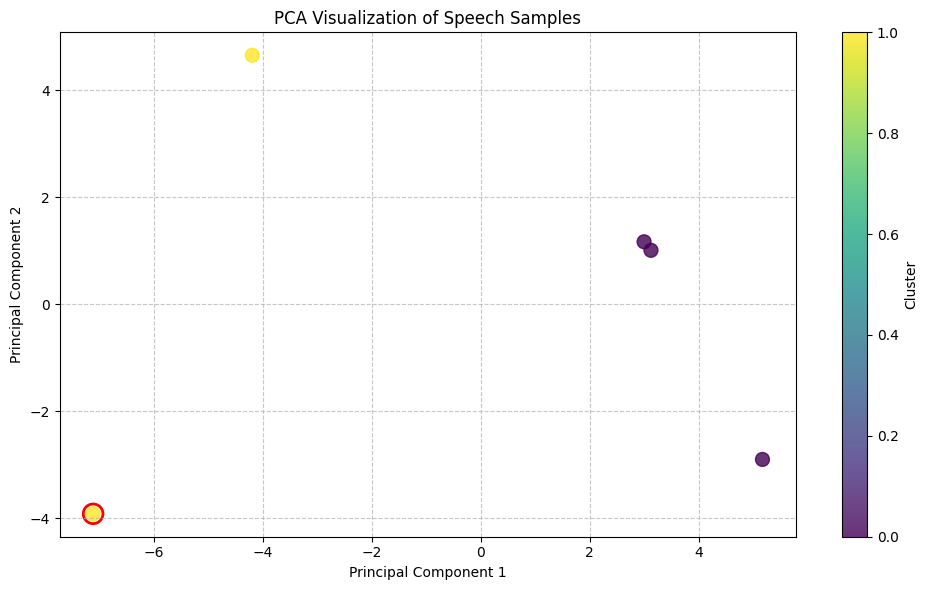

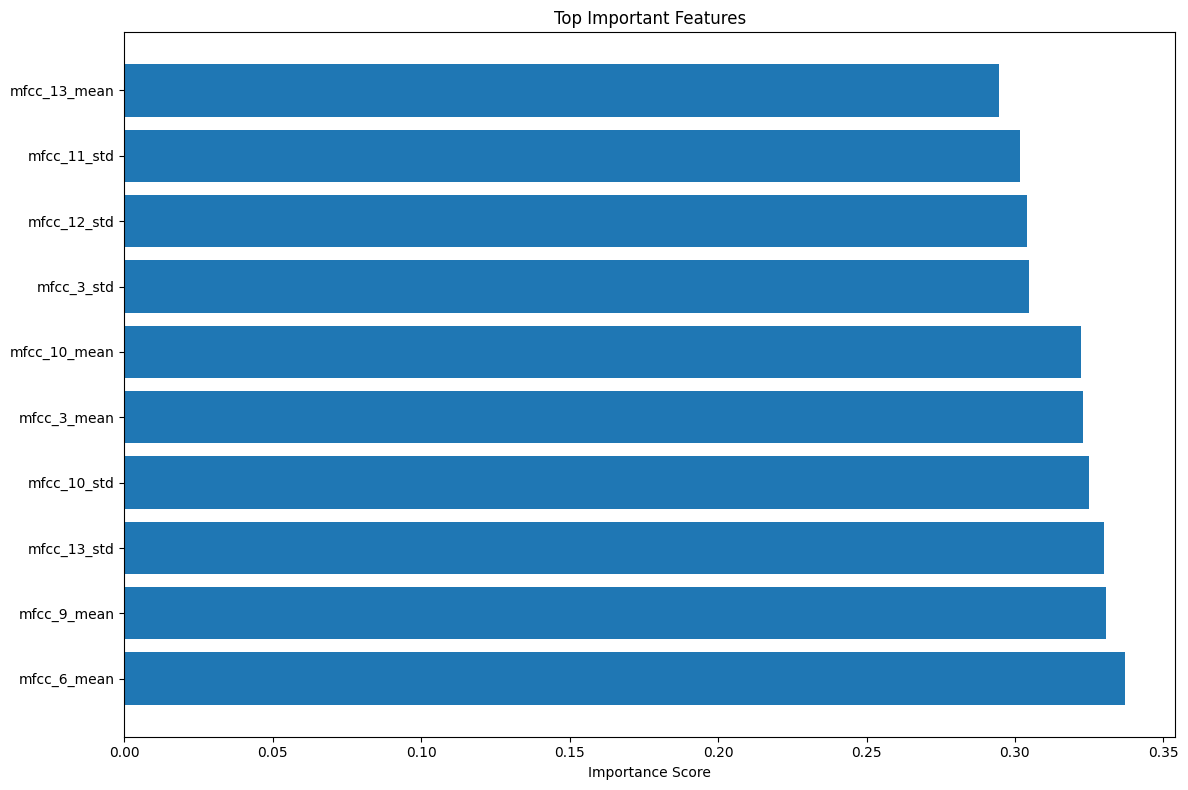

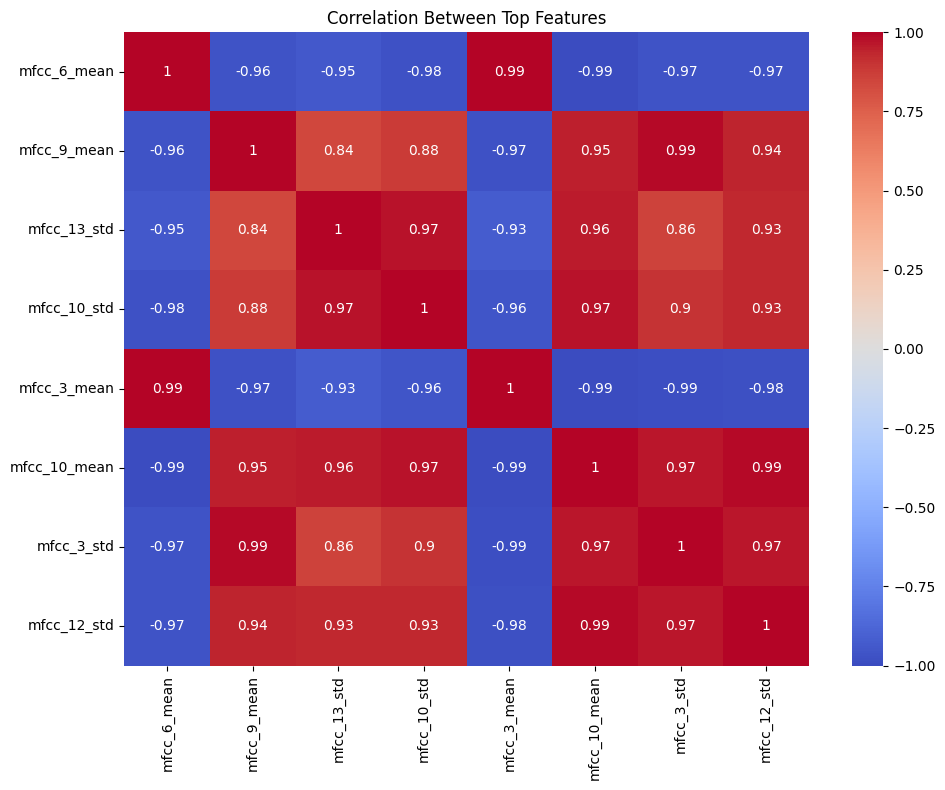

In [19]:
if __name__ == "__main__":
    sample_paths = [
        "/content/1001_DFA_ANG_XX.wav",
        "/content/1001_DFA_FEA_XX.wav",
        "/content/1001_IOM_HAP_XX.wav",
        "/content/03-01-06-02-02-02-06.wav",
        "/content/03-01-08-02-02-02-24.wav"
    ]
    # Optional: Define expected responses for task-specific analysis
    task_expected_responses = {
        'naming_task': ['watch', 'key'],
        'sentence_completion': ['happy', 'completed']
    }

    results = main(sample_paths, task_expected_responses=task_expected_responses)
    if not results.empty:
        results.to_csv('cognitive_decline_analysis.csv', index=False)
        print("Results saved to cognitive_decline_analysis.csv")

        # Example API usage:
        sample_result = predict_cognitive_decline_risk(sample_paths[0])
        print("\nAPI Result Example:")
        if 'error' in sample_result and sample_result['error']:
            print(f"Error: {sample_result['error']}")
        else:
            print(f"Risk Score: {sample_result['risk_score']}")
            print(f"Key Indicators: {sample_result['key_indicators']}")